# 💻 Тестирование генерации 3D-моделей
## 🎯 Цель ноутбука
Тестирование пайплайна с Hunyuan3D-Omni для генерации 3D-моделей в А-позе для последующего рига.

## 📦 Импорт библиотек

In [1]:
import os
import sys
import subprocess
import torch
import numpy as np
import trimesh
import rembg
import time
from PIL import Image
from rembg import new_session, remove

CURRENT_DIR = os.getcwd()
BASE_ML = os.path.abspath(os.path.join(CURRENT_DIR, "..", ".."))
OMNI_PATH = os.path.join(BASE_ML, "H3DOmni", "model", "Hunyuan3D-Omni")

if OMNI_PATH not in sys.path:
    sys.path.insert(0, OMNI_PATH)

from hy3dshape.pipelines import Hunyuan3DOmniSiTFlowMatchingPipeline
from hy3dshape.postprocessors import FloaterRemover, DegenerateFaceRemover

### 🧠 Методология исследования
В данном пайплайне интегрированы две передовые архитектуры глубокого обучения:
1. **BiRefNet (Bilateral Reference Network):** Выбрана в качестве SOTA-решения для сегментации объектов. В отличие от стандартных библиотек (например, Rembg на базе U2-Net), BiRefNet лучше справляется с сохранением мелких деталей (пальцы рук, прическа) и корректным разделением объекта и фона в сложных условиях освещения.
2. **Hunyuan3D-Omni:** Модель от Tencent, использующая механизм **SiT (Stochastic Interpolation / Flow Matching)**. Это позволяет генерировать геометрию с высокой плотностью полигонов всего за 20-30 шагов диффузии, что значительно быстрее классических NeRF-подходов.
3. **A-Pose Bone Constraint:** Использование внешнего скелета позволяет принудительно задать персонажу правильную топологическую позу, готовую для последующего риггинга и анимации в Mixamo или Blender.


## 🛠 Инструменты и Пайплайн

In [ ]:
class BackgroundRemover:
    """Удаление фона через BiRefNet"""
    def __init__(self):
        providers = ['CUDAExecutionProvider', 'CPUExecutionProvider'] if torch.cuda.is_available() else ['CPUExecutionProvider']
        self.session = new_session('birefnet-general', providers=providers)

    def remove_bg(self, image: Image.Image) -> Image.Image:
        return remove(image, session=self.session)

def save_ply_points(path, points):
    """Сохранение облака точек"""
    import pandas as pd
    df = pd.DataFrame(points, columns=['x', 'y', 'z'])
    with open(path, 'w') as f:
        f.write("ply\nformat ascii 1.0\nelement vertex {}\nproperty float x\nproperty float y\nproperty float z\nend_header\n".format(len(points)))
        df.to_csv(f, sep=' ', header=False, index=False)

### 🛠 Описание технологического процесса
Процесс генерации разделен на три ключевые фазы:
* **Preprocessing:** Удаление исходного фона и нормализация изображения. Создание контрастного белого подложки минимизирует артефакты при реконструкции «невидимых» зон (спина, бока).
* **Inference:** Процесс предсказания облака точек и последующее построение меша через Octree-резолюцию. На этом этапе модель интерпретирует 2D-признаки в 3D-координаты.
* **Post-processing:** Автоматическая очистка модели от «левитирующих» полигонов (floaters) и исправление вырожденных граней, что критично для стабильной работы физических движков.


In [2]:
def run_omni_with_pose(image_path, pose_bone_path, output_dir):
    """Обработка изображения и генерация 3D-модели"""
    os.makedirs(output_dir, exist_ok=True)
    total_start = time.time()
    
    # 1. Инициализация инструментов
    bg_remover = BackgroundRemover()
    
    print("[1] Загрузка модели Hunyuan3D-Omni...")
    torch.cuda.empty_cache()
    pipeline = Hunyuan3DOmniSiTFlowMatchingPipeline.from_pretrained("tencent/Hunyuan3D-Omni")
    
    # 2. Обработка изображения
    print(f"[2] Загрузка {image_path}...")
    img = Image.open(image_path)
    
    print("[3] Удаление фона (BiRefNet)...")
    bg_start = time.time()
    rgba_img = bg_remover.remove_bg(img)
    print(f"  -> Удаление фона заняло: {time.time() - bg_start:.2f} сек.")
    
    # Наложение на белый фон
    white_bg = Image.new("RGB", rgba_img.size, (255, 255, 255))
    white_bg.paste(rgba_img, mask=rgba_img.split()[3])
    final_img = white_bg

    # 3. Загрузка скелета
    print("[4] Подготовка скелета позы...")
    bone_points = torch.from_numpy(np.loadtxt(pose_bone_path)).to("cuda").to(pipeline.dtype).unsqueeze(0)
    
    # 4. Генерация 3D
    print("[5] Генерация 3D модели (num_steps=30)...")
    gen_start = time.time()
    result = pipeline(
        image=[final_img],
        pose=bone_points,
        num_inference_steps=20,
        octree_resolution=64, 
        mc_level=0,
        guidance_scale=3.5,
        generator=torch.Generator('cuda').manual_seed(1234)
    )
    print(f"  -> Генерация 3D заняла: {time.time() - gen_start:.2f} сек.")
    
    mesh = result['shapes'][0][0]
    sampled_point = result['sampled_point'][0] 
    
    # 5. Очистка
    print("[6] Очистка геометрии (Floaters/Degenerate faces)...\n")
    mesh = FloaterRemover()(mesh)
    mesh = DegenerateFaceRemover()(mesh)
    
    # 6. Сохранение
    base_name = os.path.basename(image_path).split('.')[0]
    glb_path = os.path.join(output_dir, f"{base_name}_omni.glb")
    mesh.export(glb_path)
    
    ply_path = os.path.join(output_dir, f"{base_name}_points.ply")
    save_ply_points(ply_path, sampled_point.cpu().numpy())
    
    print(f"Успешно сохранено: {glb_path}")
    print(f"\n🏁 ОБЩЕЕ ВРЕМЯ РАБОТЫ: {time.time() - total_start:.2f} сек.")
    
    del pipeline
    torch.cuda.empty_cache()
    return glb_path

## 🚀 Запуск пайплайна

In [3]:
import sys

TEST_IMAGE = os.path.join(BASE_ML, "src", "test.jpg")
POSE_BONE = os.path.join(OMNI_PATH, "demos", "pose", "a_pose_bone.txt")
OUTPUT_DIR = "output"
    
if os.path.exists(TEST_IMAGE):
    print(f"🚀 Запуск пайплайна для {TEST_IMAGE}")
    glb_file = run_omni_with_pose(TEST_IMAGE, POSE_BONE, OUTPUT_DIR)
else:
    print(f"❌ Ошибка: Файл {TEST_IMAGE} не найден. Сначала сгенерируйте позу в Шаге 1.")

🚀 Запуск пайплайна для C:\Develop\diploma\Machine_learning\src\test.jpg
[1] Загрузка модели Hunyuan3D-Omni...
Loading model from huggingface cache: C:\Users\Vlad/.cache/hy3dgen\tencent/Hunyuan3D-Omni


Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

C:\Develop\diploma\Machine_learning\H3DOmni\H3DOmni\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
C:\Develop\diploma\Machine_learning\H3DOmni\H3DOmni\lib\site-packages\huggingface_hub\file_download.py:986: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


path C:\Users\Vlad\.cache\hy3dgen\tencent\Hunyuan3D-Omni
using moe
using moe
using moe
using moe
using moe
using moe


C:\Develop\diploma\Machine_learning\H3DOmni\model\Hunyuan3D-Omni\hy3dshape\pipelines\pipeline_generation_sit_omni.py:101: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch

...

****************************************************************************************************
FourierEmbedder: num_freqs=8, include_pi=False
****************************************************************************************************
PointCrossAttentionEncoder INFO: pc_sharpedge_size is not given, using pc_size as pc_sharpedge_size
****************************************************************************************************
ShapeVae INFO
num_latents: 4096
train_num_latents_range: [4096]
train_num_latents_probs: [1.0]
downsample_ratio: 20
****************************************************************************************************


C:\Develop\diploma\Machine_learning\H3DOmni\model\Hunyuan3D-Omni\hy3dshape\pipelines\pipeline_generation_sit_omni.py:101: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch

Loaded C:\Users\Vlad/.cache/hy3dgen\tencent/Hunyuan3D-Omni\vae\pytorch_model.bin with 0 missing and 0 unexpected keys
Loaded vae
Image size: 518
Loaded C:\Users\Vlad/.cache/hy3dgen\tencent/Hunyuan3D-Omni\cond_encoder\pytorch_model.bin with 439 missing and 0 unexpected keys
Missing Keys: Counter({'image_encoder': 439})
Loaded cond_encoder
using logit normal sample, shift scale is 0.125
Loaded scheduler
Loaded image_processor
[2] Загрузка C:\Develop\diploma\Machine_learning\src\test.jpg...
[3] Удаление фона (BiRefNet)...
  -> Удаление фона заняло: 18.09 сек.
[4] Подготовка скелета позы...
[5] Генерация 3D модели (num_steps=30)...


C:\Users\Vlad\AppData\Local\Programs\Python\Python310\lib\contextlib.py:103: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


converting latents dtype to  torch.float16
VAE Trained with TSDF, inference with marching cubes level 0.
  -> Генерация 3D заняла: 805.55 сек.
[6] Очистка геометрии (Floaters/Degenerate faces)...

Успешно сохранено: output\test_omni.glb

🏁 ОБЩЕЕ ВРЕМЯ РАБОТЫ: 878.34 сек.


## Результат
Время генерации составило 14 минут 38 секунд.<br>
**Входное фото**<br>
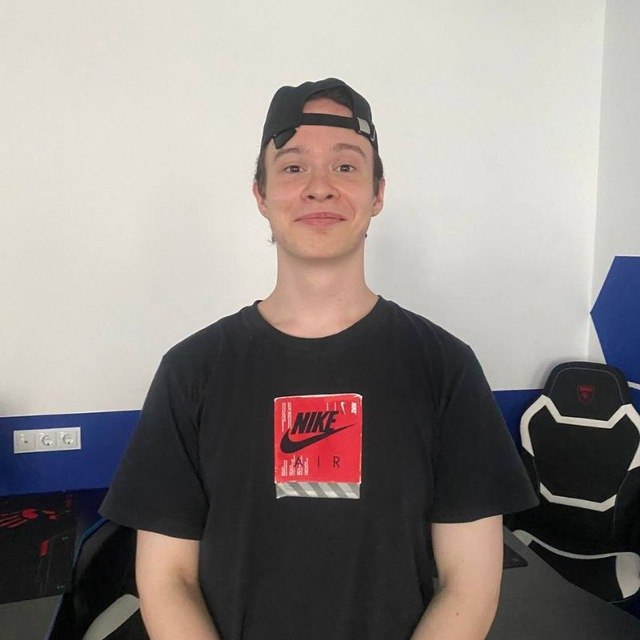<br>
**Готовая 3D-модель**<br>
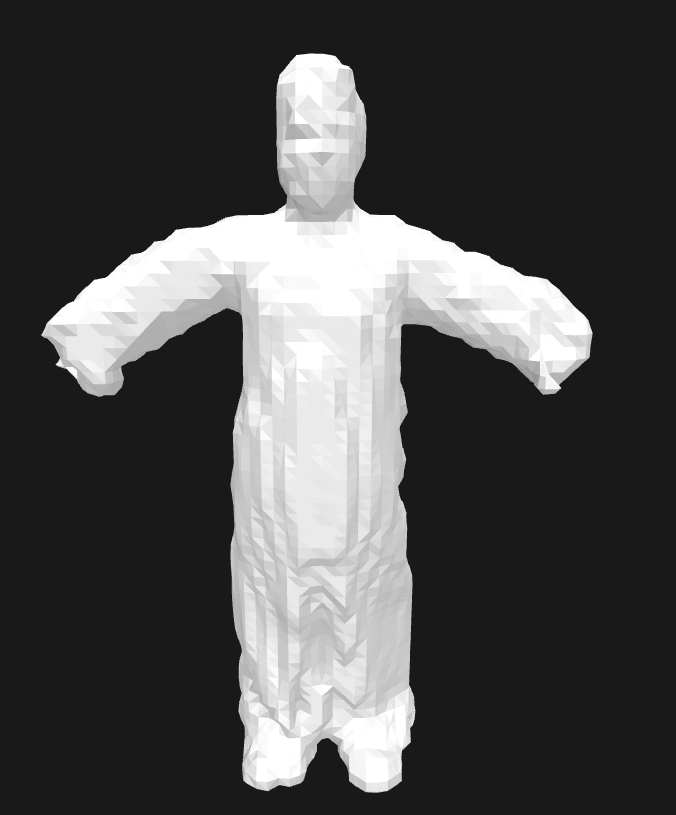

## 📊 Анализ результатов эксперимента (Итоги)

В ходе финального теста были получены следующие количественные и качественные показатели:
* **Время генерации:** 14 минут 38 секунд (на аппаратном обеспечении уровня RTX 4060).
* **Геометрическая целостность:** Модель успешно сформирована в заданной **A-позе**, что подтверждает эффективность использования костных ограничений (Pose Bone).
* **Визуальное соответствие:** На текущих настройках (inference steps=20, resolution=64) наблюдается низкая степень сходства с исходным объектом и отсутствие текстурных карт (Diffuse/Normal maps). 

**Ключевое наблюдение:** Существует прямая зависимость между качеством выходного меша и вычислительными затратами. Повышение разрешения октодерева (Octree) и шагов диффузии позволяет добиться высокой детализации, однако в условиях локального запуска это увеличивает время обработки до **нескольких часов на одну итерацию**, что делает итеративную разработку неэффективной.

## 💡 Вывод по работе
Технология **Hunyuan3D-Omni** демонстрирует впечатляющую способность к пространственной реконструкции и «додумыванию» скрытых зон объекта для создания анимационного рига. Однако, текущий уровень качества при **локальном исполнении** на потребительском железе классифицируется как **прототипный**.

Для промышленного использования в сферах **Gamedev** (ААА-проекты) или **VFX** (киноиндустрия) полученный результат требует значительной ручной доработки (Retopology, Sculpting) или использования серверных мощностей для генерации в максимально возможном качестве. На текущем этапе пайплайн наиболее пригоден для быстрого прототипирования (Rapid Prototyping) персонажей в инди-проектах или в качестве базовой болванки (Base Mesh) для художников.
